# Baseline forecaster



In forecasting modeling, a **baseline** serves as a basic, often simplistic model that acts as a fundamental reference for evaluating the performance of more complex models. It provides a baseline forecast using simple techniques that do not rely on sophisticated algorithms or extensive data analysis. Common examples of baseline strategies include:

+ **Last Observed Value:** Uses the last observed value as a forecast for all future periods.

+ **Moving Average:** In this technique, the average of the last few observations is calculated and used as a forecast for the next period. For example, a 3-period moving average would use the average of the last three observations.

+ **Last Equivalent Date (Seasonal Naive Forecasting):** Extends the concept of the last observed value by considering the corresponding period in the previous season (e.g., the same working day from the previous week) as the forecast for the current period.

The primary goal of establishing a baseline is to **provide a benchmark** against which the performance of more advanced predictive models can be evaluated. If the model does not outperform the baseline, it may indicate that there is a fundamental problem with the approach or that the added complexity is not justified by the available data. This underscores the importance of carefully evaluating the appropriateness of complex models relative to the simplicity and effectiveness of baseline models.

## ForecasterEquivalentDate

The <code>[ForecasterEquivalentDate](../api/forecasterequivalentdate.html)</code> class from `skforecast.recursive` allows the creation of a baseline forecast based on the concept of equivalent dates. In this context, an equivalent date is a historical date that has similar characteristics to the target date. The forecast for a given date is based on the value observed on the last *n* equivalent dates.
    
The behavior of the forecast is primarily controlled by two arguments:

+ `offset`: This parameter determines **how many steps back** in time to go to find the most recent equivalent date for the target period. When given as an integer, `offset` represents the number of steps to go back in time. For example, if the frequency of the time series is daily, `offset = 7` means that the most recent data similar to the target period is the value observed 7 days ago. Additionally, it is possible to use [Pandas DateOffsets](https://pandas.pydata.org/docs/reference/offset_frequency.html) to move back a given number of valid dates. For example, `Bday(2)` can be used to move back two business days.

+ `n_offsets`: This parameter determines the **number of equivalent** dates to use in the prediction. If `n_offsets` is greater than 1, the values at the equivalent dates are aggregated using the specified aggregation function, `agg_func`. For example, if the frequency of the time series is daily, `offset = 7`, `n_offsets = 2`, and `agg_func = np.mean`, the predicted value will be the mean of the values observed 7 and 14 days ago.

The common baseline strategies map to the following parameter settings:

| Baseline strategy | `offset` | `n_offsets` | `agg_func` |
|:------------------|:--------:|:-----------:|:----------:|
| Last observed value | `1` | `1` | — |
| Moving average (last *k* values) | `1` | `k` | `np.mean` |
| Seasonal naive (same period last season) | season length | `1` | — |
| Mean of the last *k* seasons | season length | `k` | `np.mean` |


<div class="admonition note" name="html-admonition" style="background: rgba(255,145,0,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #ff9100; border-color: #ff9100; padding-left: 10px; padding-right: 10px">

<p class="title">
    <i style="font-size: 18px; color:#ff9100; border-color: #ff1744;"></i>
    <b style="color: #ff9100;"> <span style="color: #ff9100;">&#9888;</span> Warning</b>
</p>

Within a forecast horizon the equivalent-date baseline does not roll: it computes its predictors once from the observed history, so a configuration such as <code>'3-month moving average'</code> (<code>offset=1, n_offsets=3</code>) returns the mean of the last three <b>observed</b> values for every step of the fold, not a rolling average that updates step by step. The same applies when <code>offset</code> is a pandas <code>DateOffset</code>.
</div>

<div class="admonition note" name="html-admonition" style="background: rgba(0,184,212,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00b8d4; border-color: #00b8d4; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00b8d4;"></i>
    <b style="color: #00b8d4;">✏️ Note</b>
</p>

<code>ForecasterEquivalentDate</code> is designed to integrate seamlessly with other functionality offered by skforecast, such as backtesting. This makes it easy to obtain the baseline for a given period.

</div>

## Libraries and data

In [1]:
# Libraries
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from skforecast.datasets import fetch_dataset
from skforecast.recursive import ForecasterEquivalentDate
from skforecast.model_selection import (
    TimeSeriesFold, 
    backtesting_forecaster, 
    grid_search_equivalent_date
)
from skforecast.plot import set_dark_theme, plot_prediction_intervals

╭──────────────────────────────── fuel_consumption ────────────────────────────────╮
│ Description:                                                                     │
│ Monthly fuel consumption in Spain from 1969-01-01 to 2022-08-01.                 │
│                                                                                  │
│ Source:                                                                          │
│ Obtained from Corporación de Reservas Estratégicas de Productos Petrolíferos and │
│ Corporación de Derecho Público tutelada por el Ministerio para la Transición     │
│ Ecológica y el Reto Demográfico. https://www.cores.es/es/estadisticas            │
│                                                                                  │
│ URL:                                                                             │
│ https://raw.githubusercontent.com/skforecast/skforecast-                         │
│ datasets/main/data/consumos-combustibles-mensual.csv                             │
│                                                                                  │
│ Shape: 644 rows x 5 columns                                                      │
╰──────────────────────────────────────────────────────────────────────────────────╯

date
1969-01-01    166875.2129
1969-02-01    155466.8105
1969-03-01    184983.6699
1969-04-01    202319.8164
Freq: MS, Name: litters, dtype: float64

Train dates : 1969-01-01 00:00:00 --- 1980-01-01 00:00:00  (n=133)
Test dates  : 1980-02-01 00:00:00 --- 1985-01-01 00:00:00  (n=60)


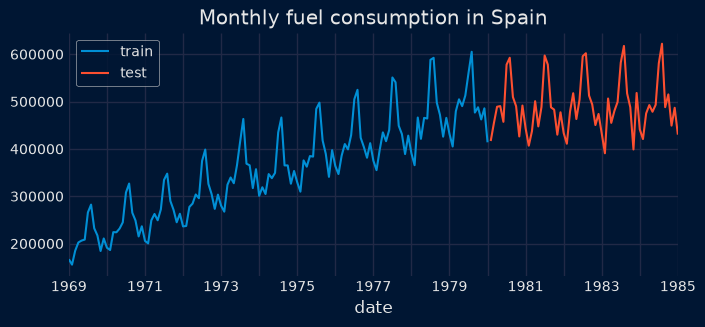

In [2]:
# Download data
# ======================================================================================
data = fetch_dataset('fuel_consumption')
data = data.rename(columns={'Gasolinas': 'litters'})
data.index.name = 'date'
data = data.loc[:'1985-01-01 00:00:00', 'litters']
display(data.head(4))

# Train-test dates
# ======================================================================================
end_train = '1980-01-01 23:59:59'
data_train = data.loc[:end_train]
data_test  = data.loc[end_train:]

print(f"Train dates : {data_train.index.min()} --- {data_train.index.max()}  (n={len(data_train)})")
print(f"Test dates  : {data_test.index.min()} --- {data_test.index.max()}  (n={len(data_test)})")

# Plot
# ======================================================================================
set_dark_theme()
fig, ax = plt.subplots(figsize=(7, 3))
data_train.plot(ax=ax, label='train')
data_test.plot(ax=ax, label='test')
ax.set_title('Monthly fuel consumption in Spain')
ax.legend();

## Create and train forecaster

In [3]:
# Create and fit forecaster
# ==============================================================================
forecaster = ForecasterEquivalentDate(
                 offset    = pd.DateOffset(months=12),
                 n_offsets = 2,
                 agg_func  = np.mean
             )

forecaster.fit(y=data_train)
forecaster

======================== 
ForecasterEquivalentDate 
======================== 
Offset: <DateOffset: months=12> 
Number of offsets: 2 
Aggregation function: mean 
Window size: 24 
Series name: litters 
Training range: [Timestamp('1969-01-01 00:00:00'), Timestamp('1980-01-01 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <MonthBegin> 
Creation date: 2026-08-21 16:16:21 
Last fit date: 2026-08-21 16:16:21 
Skforecast version: 0.24.0 
Python version: 3.14.3 
Forecaster id: None

## Prediction

In [4]:
# Predict
# ==============================================================================
predictions = forecaster.predict(steps=len(data_test))
predictions.head(3)

1980-02-01    385298.35315
1980-03-01    472815.89325
1980-04-01    462944.81705
Freq: MS, Name: pred, dtype: float64

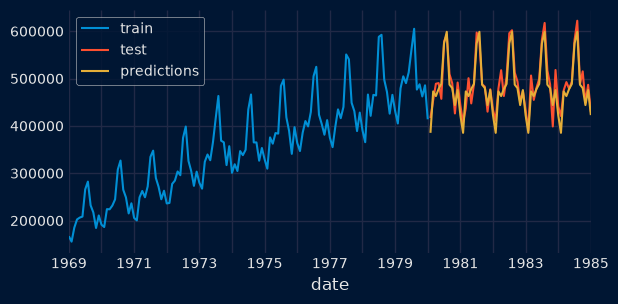

In [5]:
# Plot predictions
# ==============================================================================
fig, ax = plt.subplots(figsize=(6, 3))
data_train.plot(ax=ax, label='train')
data_test.plot(ax=ax, label='test')
predictions.plot(ax=ax, label='predictions')
ax.legend();

In [6]:
# Prediction error
# ==============================================================================
error_mae = mean_absolute_error(
                y_true = data_test,
                y_pred = predictions
            )

print(f"Test error (mae): {error_mae}")


Test error (mae): 16785.29897833333


## Probabilistic forecasting

Conformal prediction is a framework for constructing prediction intervals that are guaranteed to contain the true value with a specified probability (coverage probability). It works by combining the predictions of a point-forecasting model with its past residuals, differences between previous predictions and actual values. These residuals help estimate the uncertainty in the forecast and determine the width of the prediction interval that is then added to the point forecast.

To learn more about conformal predictions in **skforecast**, visit the [Probabilistic Forecasting: Conformal Prediction](../user_guides/probabilistic-forecasting-conformal-prediction.html) user guide.

In [7]:
# Store in-sample residuals
# ==============================================================================
# Residuals are not stored during `fit` unless `store_in_sample_residuals=True`,
# so they are computed here to enable conformal prediction intervals.
forecaster.set_in_sample_residuals(y=data_train)

In [8]:
# Prediction intervals
# ==============================================================================
predictions = forecaster.predict_interval(
    steps                   = len(data_test),
    interval                = [0.1, 0.9],  # 80% prediction interval
    method                  = 'conformal',
    use_in_sample_residuals = True
)

predictions.head(4)

,pred,lower_bound,upper_bound
1980-02-01,385298.35315,334204.43875,436392.26755
1980-03-01,472815.89325,413163.96550,532467.82100
1980-04-01,462944.81705,403292.88930,522596.74480
1980-05-01,477889.17740,418237.24965,537541.10515


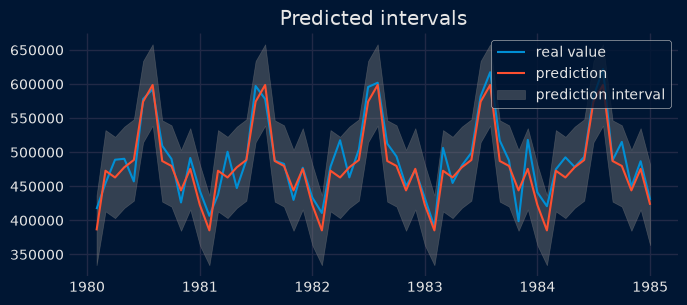

In [9]:
# Plot intervals
# ==============================================================================
plot_prediction_intervals(
    predictions         = predictions,
    y_true              = data_test,
    target_variable     = "litters",
    title               = "Predicted intervals",
    kwargs_fill_between = {'color': 'gray', 'alpha': 0.4, 'zorder': 1}
)

## Backtesting

In [10]:
# Backtesting
# ==============================================================================
cv = TimeSeriesFold(
         steps              = 15,
         initial_train_size = len(data_train),
         refit              = True
     )

metric, predictions = backtesting_forecaster(
                          forecaster = forecaster,
                          y          = data,
                          cv         = cv,
                          metric     = 'mean_absolute_error'
                      )

print("Backtest error:")
metric

  0%|          | 0/4 [00:00<?, ?it/s]

Backtest error:


,mean_absolute_error
0,18575.076906


In [11]:
# Backtesting predictions
# ==============================================================================
predictions.head(4)

,fold,pred
1980-02-01,0,385298.35315
1980-03-01,0,472815.89325
1980-04-01,0,462944.81705
1980-05-01,0,477889.17740


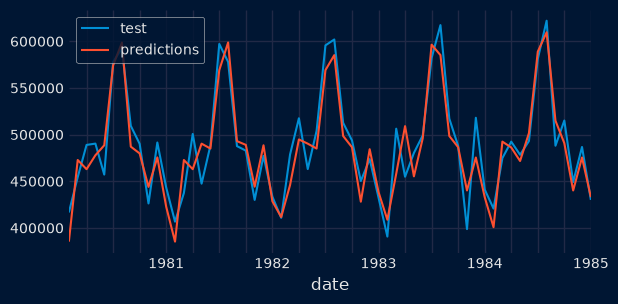

In [12]:
# Plot backtesting predictions
# ==============================================================================
fig, ax = plt.subplots(figsize=(6, 3))
data_test.plot(ax=ax, label='test')
predictions['pred'].plot(ax=ax, label='predictions')
ax.legend();

## Searching for the best configuration

Although `ForecasterEquivalentDate` has no trainable estimator, its behaviour depends on a few configuration parameters (`offset`, `n_offsets`, and `agg_func`) that jointly define **which** past values are used and **how** they are aggregated. Finding the best combination is itself a small search problem: the function [`grid_search_equivalent_date`](../api/model_selection.html#skforecast.model_selection._search.grid_search_equivalent_date) evaluates a set of candidate configurations using time series backtesting and ranks them by the selected metric.

In [16]:
# Search over baseline configurations
# ==============================================================================
cv = TimeSeriesFold(
         steps              = 15,
         initial_train_size = len(data_train),
         refit              = False
     )

# Each dictionary defines one explicit baseline configuration.
# `offset` can be an integer (number of steps back) or a pandas DateOffset.
param_grid = [
    # Integer offset: number of steps back (monthly data -> months)
    {'alias': 'Last month',             'offset': 1,  'n_offsets': 1, 'agg_func': np.mean},
    {'alias': '3-month moving average', 'offset': 1,  'n_offsets': 3, 'agg_func': np.mean},
    {'alias': 'Same month last year',   'offset': 12, 'n_offsets': 1, 'agg_func': np.mean},
    {'alias': 'Mean of last 2 years',   'offset': 12, 'n_offsets': 2, 'agg_func': np.mean},
    # pandas DateOffset: calendar-aware step (requires a DatetimeIndex with frequency)
    {'alias': 'Mean of last 3 years',   'offset': pd.DateOffset(months=12), 'n_offsets': 3, 'agg_func': np.mean},
    {'alias': 'Median of last 3 years', 'offset': pd.DateOffset(months=12), 'n_offsets': 3, 'agg_func': np.median},
]

# Alternatively, pass a dict to evaluate all combinations (Cartesian product).
# Use this form only when every combination is meaningful:
# param_grid = {
#     'offset':    [1, 12],
#     'n_offsets': [1, 2, 3],
#     'agg_func':  [np.mean, np.median],
# }  # -> 2 x 3 x 2 = 12 configurations

results = grid_search_equivalent_date(
              forecaster  = forecaster,
              y           = data,
              cv          = cv,
              param_grid  = param_grid,
              metric      = 'mean_absolute_error',
              return_best = True,
          )

results

params grid:   0%|          | 0/6 [00:00<?, ?it/s]

,alias,params,mean_absolute_error,offset,n_offsets,agg_func
0,Mean of last 3 years,"{'offset': <DateOffset: months=12>, 'n_offsets...",17969.624487,<DateOffset: months=12>,3,mean
1,Mean of last 2 years,"{'offset': 12, 'n_offsets': 2, 'agg_func': <fu...",18575.076906,12,2,mean
2,Median of last 3 years,"{'offset': <DateOffset: months=12>, 'n_offsets...",20038.362477,<DateOffset: months=12>,3,median
3,Same month last year,"{'offset': 12, 'n_offsets': 1, 'agg_func': <fu...",20099.924027,12,1,mean
4,3-month moving average,"{'offset': 1, 'n_offsets': 3, 'agg_func': <fun...",55317.400922,1,3,mean
5,Last month,"{'offset': 1, 'n_offsets': 1, 'agg_func': <fun...",63229.415890,1,1,mean
